Все модели прогоняются через одну функцию `eval_blackbox.eot_pgd_acc`:

| параметр | значение |
|---|---|
| steps | 20 |
| alpha | `eps * 2.5 / steps` |
| детерминированные модели (без шума) | PGD (`eot=0`) |
| шумные модели | EOT-PGD, `eot=20` |
| выборка | полный тест STL-10 (8000) |
| eps | 2/255 и 4/255 |

Для шумных моделей плоский PGD даёт завышенную оценку (градиент искажается шумом),
поэтому используется EOT-PGD с усреднением градиента по `eot` реализациям шума.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import torch
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 300)
pd.set_option('display.expand_frame_repr', False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS = [2/255, 4/255]
print(device)

cuda


## 1. White-box: результаты

Таблица заполнена числами прогонов.
`x_vanilla` — отношение robust@eps2 к baseline.

In [2]:
final = [
    dict(model='vanilla',              family='baseline', noise=False, clean=0.883, eps2=0.056, eps4=0.000, attack='PGD'),
    dict(model='siamese frozen',       family='siamese',  noise=False, clean=0.823, eps2=0.165, eps4=0.018, attack='PGD'),
    dict(model='tile d1 soft+noise',   family='tile',     noise=True,  clean=0.843, eps2=0.249, eps4=0.025, attack='EOT-PGD'),
    dict(model='siamese freeze+noise', family='siamese',  noise=True,  clean=0.793, eps2=0.258, eps4=0.037, attack='EOT-PGD'),
    dict(model='siamese soft+noise',   family='siamese',  noise=True,  clean=0.801, eps2=0.273, eps4=0.047, attack='EOT-PGD'),
    dict(model='tile conv1 (tap)',       family='tile',     noise=True,  clean=0.791, eps2=0.508, eps4=0.235, attack='EOT-PGD'),
    dict(model='tile late-simkin conv1', family='tile',     noise=True,  clean=0.842, eps2=0.562, eps4=0.254, attack='EOT-PGD'),
]
fdf = pd.DataFrame(final)
fdf['x_vanilla'] = (fdf.eps2 / fdf.loc[fdf.model == 'vanilla', 'eps2'].values[0]).round(1)
fdf.sort_values('eps2', ascending=False).reset_index(drop=True)

,model,family,noise,clean,eps2,eps4,attack,x_vanilla
0,tile late-simkin conv1,tile,True,0.842,0.562,0.254,EOT-PGD,10.0
1,tile conv1 (tap),tile,True,0.791,0.508,0.235,EOT-PGD,9.1
2,siamese soft+noise,siamese,True,0.801,0.273,0.047,EOT-PGD,4.9
3,siamese freeze+noise,siamese,True,0.793,0.258,0.037,EOT-PGD,4.6
4,tile d1 soft+noise,tile,True,0.843,0.249,0.025,EOT-PGD,4.4
5,siamese frozen,siamese,False,0.823,0.165,0.018,PGD,2.9
6,vanilla,baseline,False,0.883,0.056,0.000,PGD,1.0


Графики: слева — clean против robust@eps2 (маркер `o` — модель с нейронным шумом,
`s` — без); справа — robust@eps2 с указанием типа атаки.

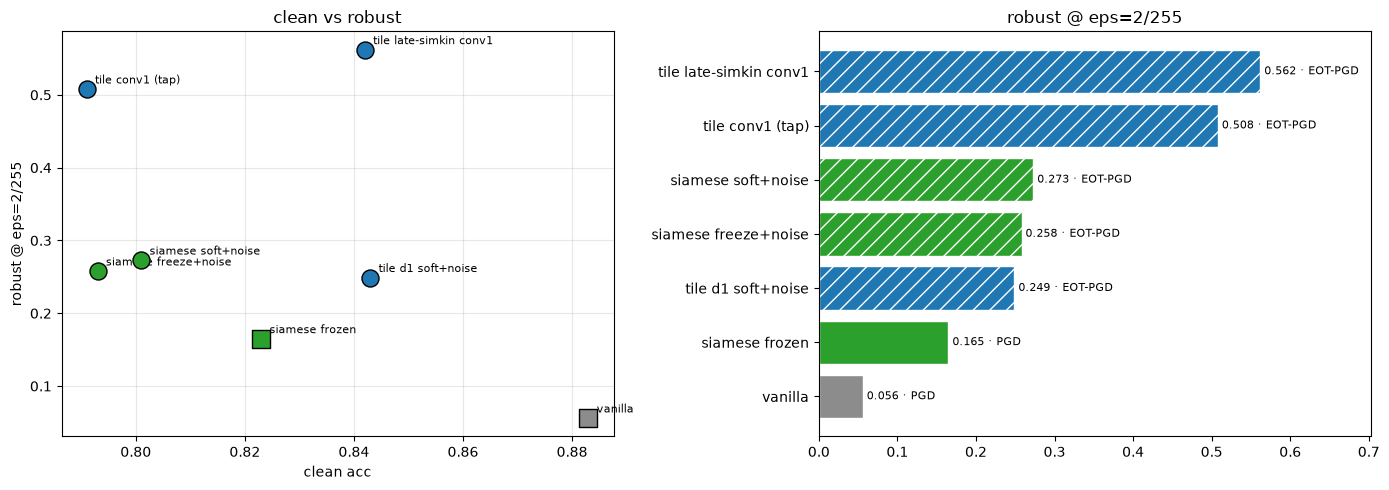

In [17]:
fam_colors = {'baseline': '#8c8c8c', 'siamese': '#2ca02c', 'tile': '#1f77b4'}
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for _, r in fdf.iterrows():
    ax[0].scatter(r.clean, r.eps2, s=150, color=fam_colors[r.family],
                  marker=('o' if r.noise else 's'), edgecolor='k', zorder=3)
    ax[0].annotate(r.model, (r.clean, r.eps2), fontsize=8,
                   xytext=(6, 4), textcoords='offset points')
ax[0].set_xlabel('clean acc'); ax[0].set_ylabel('robust @ eps=2/255')
ax[0].set_title('clean vs robust'); ax[0].grid(alpha=.3)

d = fdf.sort_values('eps2')
ax[1].barh(d.model, d.eps2, color=[fam_colors[f] for f in d.family],
           hatch=['//' if n else '' for n in d.noise], edgecolor='white')
for i, (v, a) in enumerate(zip(d.eps2, d.attack)):
    ax[1].text(v + 0.005, i, f'{v:.3f} · {a}', va='center', fontsize=8)
ax[1].set_title('robust @ eps=2/255'); ax[1].set_xlim(0, d.eps2.max() * 1.25)
plt.tight_layout(); plt.show()

Зависимость robust от силы атаки (eps = 2/255 и 4/255).

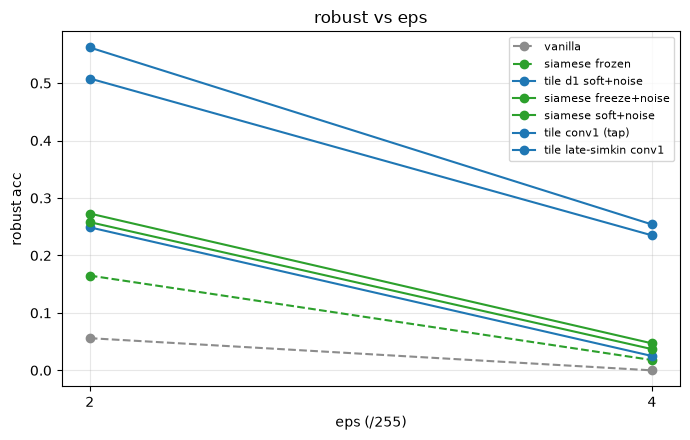

In [4]:
plt.figure(figsize=(7, 4.5))
for _, r in fdf.iterrows():
    plt.plot([2, 4], [r.eps2, r.eps4], marker='o', color=fam_colors[r.family],
             linestyle=('-' if r.noise else '--'), label=r.model)
plt.xticks([2, 4]); plt.xlabel('eps (/255)'); plt.ylabel('robust acc')
plt.title('robust vs eps'); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Запуск white-box оценки для новых моделей

`eot=20` для шумных, `eot=0` для детерминированных.

In [5]:
from scripts.eval_blackbox import load_model, get_loader01, eot_pgd_acc, _clean_acc
from scripts.eval_blackbox import square_acc, craft_transfer, acc_on

/root/vk_work/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# ld = get_loader01(n=None, batch_size=128)
# WB_CSV = 'output/final_results.csv'

# # (имя, ckpt, arch, noise_sigma)
# models = [
#     ('vanilla',             '<vanilla ckpt>',                        'siamese', 0.0),
#     ('siamese frozen',      'models/ResNetSIMv2_frozen_best.pth',    'siamese', 0.0),
#     ('siamese freeze+noise','models/ResNetSIM_frozen_noisy_best.pth','siamese', 0.5),
#     ('siamese soft+noise',  'models/ResNetSIM_soft_noisy_best.pth',  'siamese', 0.5),
#     ('tile d1 soft+noise',  'models/ResNetTile_noisy_1depth_best.pt','tile',    0.5),
# ]

# done = pd.read_csv(WB_CSV) if os.path.exists(WB_CSV) else pd.DataFrame(columns=['model','clean','eps','robust','attack'])
# rows, seen = done.to_dict('records'), set(done.model)

# for name, ckpt, arch, ns in models:
#     if name in seen:
#         print(f'skip {name}'); continue
#     m = load_model(ckpt, noise_sigma=ns, device=device, arch=arch)
#     eot = 20 if ns > 0 else 0
#     clean = round(_clean_acc(m, ld, device), 3)
#     for e in EPS:
#         r = round(eot_pgd_acc(m, ld, e, device, steps=20, eot=eot), 3)
#         rows.append(dict(model=name, clean=clean, eps=f'{e*255:.0f}/255', robust=r,
#                          attack='EOT-PGD' if eot else 'PGD'))
#         print(f'{name:22s} eps={e*255:.0f}  clean={clean}  robust={r}')
#     del m; torch.cuda.empty_cache()

# os.makedirs('output', exist_ok=True)
# pd.DataFrame(rows).to_csv(WB_CSV, index=False)
# pd.DataFrame(rows)

## 3. Black-box: Square и Transfer

Атакующий не имеет доступа к весам цели.

- **Square** — score-based: доступен только выход модели, градиенты не используются.
  Параметр `n_queries=2000` (число запросов на картинку).
- **Transfer** — PGD крафтится на суррогатной модели и переносится на цель;
  обращений к цели при построении возмущения нет.

In [7]:
# ld_bb = get_loader01(n=2000, batch_size=512, seed=0)
# BB_CSV = 'output/blackbox_results.csv'

# # суррогат для transfer — детерминированная модель (noise_sigma=0)
# surrogate = load_model('models/ResNetSIMv2_frozen_best.pth', noise_sigma=0.0,
#                        device=device, arch='siamese')
# adv = {e: craft_transfer(surrogate, ld_bb, e, device, steps=20) for e in EPS}

# targets = [
#     ('siamese frozen',      'models/ResNetSIMv2_frozen_best.pth',    'siamese', 0.0),
#     ('siamese freeze+noise','models/ResNetSIM_frozen_noisy_best.pth','siamese', 0.5),
#     ('siamese soft+noise',  'models/ResNetSIM_soft_noisy_best.pth',  'siamese', 0.5),
#     ('tile d1 soft+noise',  'models/ResNetTile_noisy_1depth_best.pt','tile',    0.5),
# ]

# done_bb = pd.read_csv(BB_CSV) if os.path.exists(BB_CSV) else pd.DataFrame(columns=['model','eps','square','transfer'])
# bb_rows, bb_seen = done_bb.to_dict('records'), set(done_bb.model)

# for name, ckpt, arch, ns in targets:
#     if name in bb_seen:
#         print(f'skip {name}'); continue
#     tgt = load_model(ckpt, noise_sigma=ns, device=device, arch=arch)
#     for e in EPS:
#         tr = round(acc_on(tgt, adv[e]), 3)
#         sq = round(square_acc(tgt, ld_bb, e, device, n_queries=2000), 3)
#         bb_rows.append(dict(model=name, eps=f'{e*255:.0f}/255', square=sq, transfer=tr))
#         print(f'{name:22s} eps={e*255:.0f}/255  Square={sq}  Transfer={tr}')
#     del tgt; torch.cuda.empty_cache()

# os.makedirs('output', exist_ok=True)
# pd.DataFrame(bb_rows).to_csv(BB_CSV, index=False)
# pd.DataFrame(bb_rows)

### Результаты black-box (случайная подвыборка n=2000, seed=0)

Суррогат и цель `siamese frozen` — один чекпойнт, поэтому её transfer
это white-box атака модели на саму себя и должен совпасть с её PGD из раздела 1:
0.168 vs 0.165 (eps2), 0.020 vs 0.018 (eps4). Совпало, поэтому все ок.

Свойства замера:
- Square и transfer — более слабые атаки, чем white-box PGD/EOT-PGD, поэтому их значения
  выше; white-box остаётся нижней границей (worst-case).
- Для детерминированной модели transfer с суррогатом той же архитектуры численно близок
  к её white-box PGD.
- У шумных моделей обе black-box атаки ослабляются стохастикой выхода.

In [8]:
bb = pd.DataFrame([
    dict(model='siamese frozen',       noise=False, eps=2, square=0.593, transfer=0.168),
    dict(model='siamese frozen',       noise=False, eps=4, square=0.345, transfer=0.020),
    dict(model='siamese freeze+noise', noise=True,  eps=2, square=0.787, transfer=0.667),
    dict(model='siamese freeze+noise', noise=True,  eps=4, square=0.790, transfer=0.526),
    dict(model='siamese soft+noise',   noise=True,  eps=2, square=0.782, transfer=0.654),
    dict(model='siamese soft+noise',   noise=True,  eps=4, square=0.790, transfer=0.504),
    dict(model='tile d1 soft+noise',   noise=True,  eps=2, square=0.837, transfer=0.721),
    dict(model='tile d1 soft+noise',   noise=True,  eps=4, square=0.836, transfer=0.567),
])
bb

,model,noise,eps,square,transfer
0,siamese frozen,False,2,0.593,0.168
1,siamese frozen,False,4,0.345,0.020
2,siamese freeze+noise,True,2,0.787,0.667
3,siamese freeze+noise,True,4,0.790,0.526
4,siamese soft+noise,True,2,0.782,0.654
5,siamese soft+noise,True,4,0.790,0.504
6,tile d1 soft+noise,True,2,0.837,0.721
7,tile d1 soft+noise,True,4,0.836,0.567


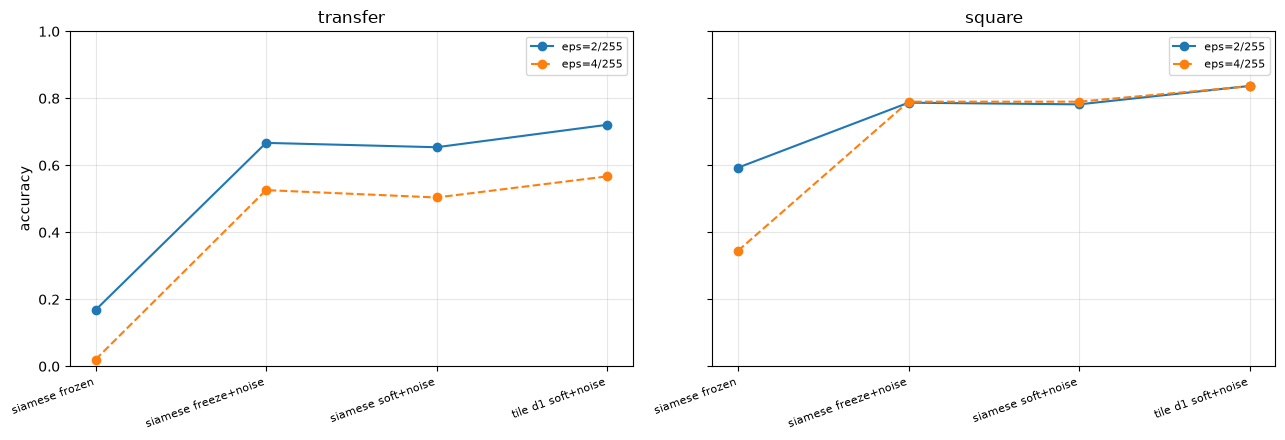

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
names = bb.model.unique()
xs = range(len(names))

for j, col in enumerate(['transfer', 'square']):
    for e, style in [(2, '-'), (4, '--')]:
        vals = [bb[(bb.model == n) & (bb.eps == e)][col].values[0] for n in names]
        ax[j].plot(list(xs), vals, marker='o', linestyle=style, label=f'eps={e}/255')
    ax[j].set_xticks(list(xs))
    ax[j].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
    ax[j].set_title(col); ax[j].grid(alpha=.3); ax[j].legend(fontsize=8)
ax[0].set_ylabel('accuracy'); ax[0].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 4. Глубина перцептивного фронт-энда

`simkin_depth` — сколько блоков входит во фронт-энд: место ветвления симкин-головы,
зона претрейна и soft-freeze, и точка вставки нейронного шума.

| depth | фронт-энд | шум после |
|---|---|---|
| 1 | stem + layer1 | layer1 |
| 2 | + layer2 | layer2 |
| 3 | + layer3 | layer3 |

Все три прогона при одинаковых условиях: тайл 128, φ_a∈{1,2,4,8}, σ=0.5, δ=0.01,
10 эпох, EOT-PGD k=10, полный тест.

,depth,clean,eps2
0,1,0.853,0.232
1,2,0.805,0.152
2,3,0.804,0.063


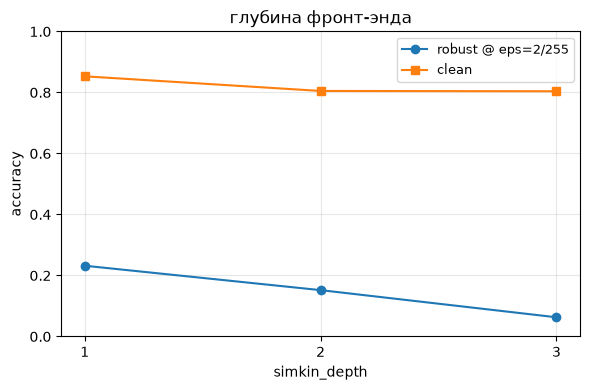

In [10]:
depth = pd.DataFrame([
    dict(depth=1, clean=0.853, eps2=0.232),
    dict(depth=2, clean=0.805, eps2=0.152),
    dict(depth=3, clean=0.804, eps2=0.063),
])
display(depth)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(depth.depth, depth.eps2, marker='o', label='robust @ eps=2/255')
ax.plot(depth.depth, depth.clean, marker='s', label='clean')
ax.set_xticks(depth.depth); ax.set_xlabel('simkin_depth'); ax.set_ylabel('accuracy')
ax.set_ylim(0, 1); ax.grid(alpha=.3); ax.legend(fontsize=9)
ax.set_title('глубина фронт-энда')
plt.tight_layout(); plt.show()

## 5. Анализ чувствительности

In [11]:
tap_sweep = pd.DataFrame([
    dict(tap='conv1', clean=0.791, eps2=0.508, eps4=0.235),
    dict(tap='stem',  clean=0.809, eps2=0.366, eps4=0.083),
    dict(tap='l1.0',  clean=0.850, eps2=0.264, eps4=0.033),
    dict(tap='l1.1',  clean=0.845, eps2=0.264, eps4=0.032),
    dict(tap='l1',    clean=0.846, eps2=0.245, eps4=0.026),
])
tap_sweep

,tap,clean,eps2,eps4
0,conv1,0.791,0.508,0.235
1,stem,0.809,0.366,0.083
2,l1.0,0.850,0.264,0.033
3,l1.1,0.845,0.264,0.032
4,l1,0.846,0.245,0.026


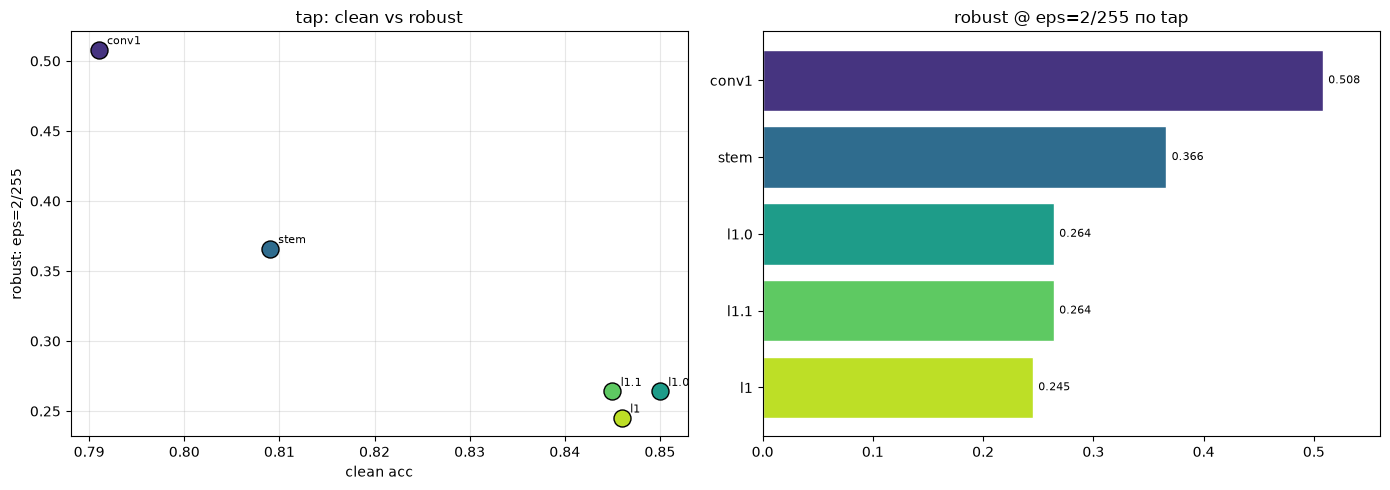

In [12]:
tap_order = ['conv1', 'stem', 'l1.0', 'l1.1', 'l1']
tcol = dict(zip(tap_order, plt.cm.viridis([0.15, 0.35, 0.55, 0.75, 0.9])))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for _, r in tap_sweep.iterrows():
    ax[0].scatter(r.clean, r.eps2, s=150, color=tcol[r.tap],
                  marker='o', edgecolor='k', zorder=3)
    ax[0].annotate(r.tap, (r.clean, r.eps2), fontsize=8,
                   xytext=(6, 4), textcoords='offset points')
ax[0].set_xlabel('clean acc'); ax[0].set_ylabel('robust: eps=2/255')
ax[0].set_title('tap: clean vs robust'); ax[0].grid(alpha=.3)

d = tap_sweep.sort_values('eps2')
ax[1].barh(d.tap, d.eps2, color=[tcol[t] for t in d.tap], edgecolor='white')
for i, v in enumerate(d.eps2):
    ax[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
ax[1].set_title('robust @ eps=2/255 по tap'); ax[1].set_xlim(0, 0.56)
plt.tight_layout(); plt.show()

In [13]:
k_sweep = pd.DataFrame([
    dict(tap='conv1', k10=0.523, k20=0.508, k40=0.499),
    dict(tap='l1',    k10=0.252, k20=0.245, k40=0.247),
])
k_sweep['drop_10_40'] = (k_sweep.k10 - k_sweep.k40).round(3)
k_sweep

,tap,k10,k20,k40,drop_10_40
0,conv1,0.523,0.508,0.499,0.024
1,l1,0.252,0.245,0.247,0.005


### Детальный разбор по слоям

In [14]:
amp2 = pd.DataFrame([
    dict(layer='conv1', van_ratio=1.43,  d1_ratio=1.42,  conv1_ratio=1.59, d1_SNR=348.80,  conv1_SNR=532.90),
    dict(layer='stem',  van_ratio=2.08,  d1_ratio=2.00,  conv1_ratio=2.27, d1_SNR=423.81,  conv1_SNR=0.54),
    dict(layer='l1.0',  van_ratio=2.51,  d1_ratio=2.60,  conv1_ratio=2.77, d1_SNR=881.49,  conv1_SNR=0.54),
    dict(layer='l1.1',  van_ratio=2.06,  d1_ratio=2.84,  conv1_ratio=2.50, d1_SNR=1014.62, conv1_SNR=0.54),
    dict(layer='l1',    van_ratio=2.31,  d1_ratio=3.06,  conv1_ratio=2.48, d1_SNR=1512.58, conv1_SNR=0.54),
    dict(layer='l2',    van_ratio=3.46,  d1_ratio=4.88,  conv1_ratio=2.96, d1_SNR=0.62,    conv1_SNR=0.55),
    dict(layer='l3',    van_ratio=7.69,  d1_ratio=9.85,  conv1_ratio=2.53, d1_SNR=1.12,    conv1_SNR=0.66),
    dict(layer='l4',    van_ratio=26.31, d1_ratio=25.24, conv1_ratio=2.23, d1_SNR=4.03,    conv1_SNR=1.52),
])
amp2

,layer,van_ratio,d1_ratio,conv1_ratio,d1_SNR,conv1_SNR
0,conv1,1.43,1.42,1.59,348.80,532.90
1,stem,2.08,2.00,2.27,423.81,0.54
2,l1.0,2.51,2.60,2.77,881.49,0.54
3,l1.1,2.06,2.84,2.50,1014.62,0.54
4,l1,2.31,3.06,2.48,1512.58,0.54
5,l2,3.46,4.88,2.96,0.62,0.55
6,l3,7.69,9.85,2.53,1.12,0.66
7,l4,26.31,25.24,2.23,4.03,1.52


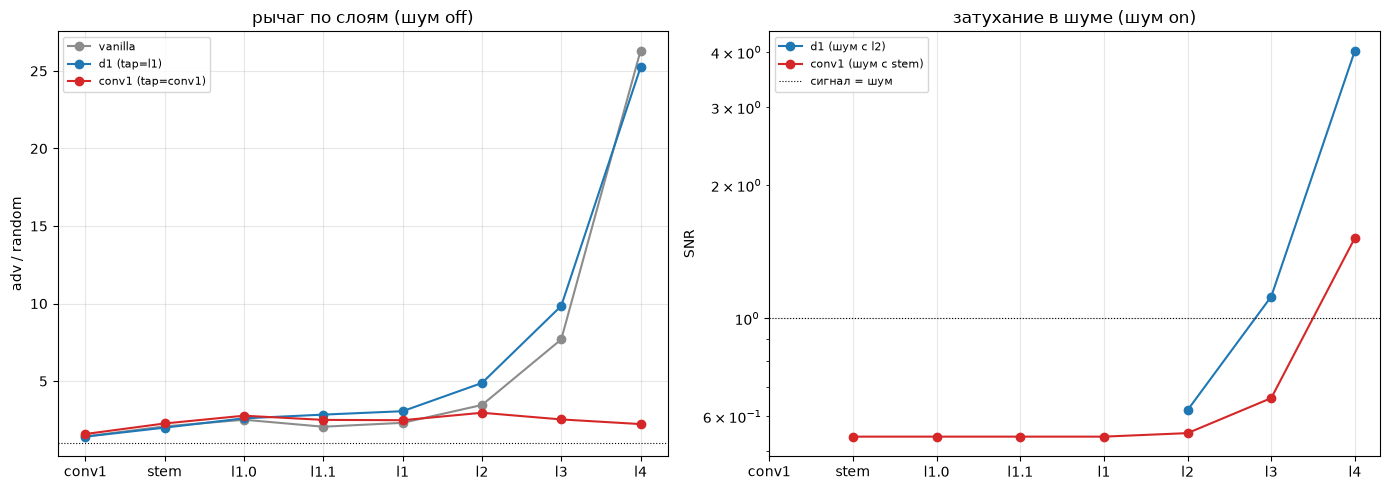

In [15]:
LYR = amp2.layer.tolist(); xi = range(len(LYR))
d1_snr = amp2.d1_SNR.where(amp2.layer.isin(['l2', 'l3', 'l4']))       # шум d1 включён с l2
c1_snr = amp2.conv1_SNR.where(~amp2.layer.isin(['conv1']))           # шум conv1 включён с stem

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(xi, amp2.van_ratio,   'o-', color='#8c8c8c', label='vanilla')
ax[0].plot(xi, amp2.d1_ratio,    'o-', color='#1f77b4', label='d1 (tap=l1)')
ax[0].plot(xi, amp2.conv1_ratio, 'o-', color='#d62728', label='conv1 (tap=conv1)')
ax[0].axhline(1, color='k', lw=.8, ls=':')
ax[0].set_xticks(list(xi)); ax[0].set_xticklabels(LYR)
ax[0].set_ylabel('adv / random'); ax[0].set_title('рычаг по слоям (шум off)'); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

ax[1].plot(xi, d1_snr, 'o-', color='#1f77b4', label='d1 (шум с l2)')
ax[1].plot(xi, c1_snr, 'o-', color='#d62728', label='conv1 (шум с stem)')
ax[1].axhline(1, color='k', lw=.8, ls=':', label='сигнал = шум')
ax[1].set_yscale('log'); ax[1].set_xticks(list(xi)); ax[1].set_xticklabels(LYR)
ax[1].set_ylabel('SNR'); ax[1].set_title('затухание в шуме (шум on)'); ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 6. Поздний Simkin (голова на l4, шум на conv1, soft-freeze хвоста)

In [ ]:
# три конфигурации разморозки хвоста; robust плоский -> устойчивость определяет позиция шума, а не дообучение
# k=20 -> 0.562, k=40 -> 0.545
late = pd.DataFrame([
    dict(tail='l4',       clean=0.842, eps2=0.562, eps4=0.254),
    dict(tail='l3_l4',    clean=0.840, eps2=0.550, eps4=0.246),
    dict(tail='l2_l3_l4', clean=0.830, eps2=0.556, eps4=0.252),
])
late

,tail,clean,eps2,eps4
0,l4,0.842,0.562,0.254
1,l3_l4,0.840,0.550,0.246
2,l2_l3_l4,0.830,0.556,0.252
